In [1]:
import pandas as pd
import numpy as np
import osmnx as ox
import networkx as nx 

## Define ZMG

In [2]:
ZMG = [
    "Guadalajara, Jalisco, Mexico",
    "Zapopan, Jalisco, Mexico",
    "San Pedro Tlaquepaque, Jalisco, Mexico",
    "Tonalá, Jalisco, Mexico",
    "Tlajomulco de Zúñiga, Jalisco, Mexico",
    "El Salto, Jalisco, Mexico"
]

## Get __Highway__ Graph (red vial SIMPLIFIED)

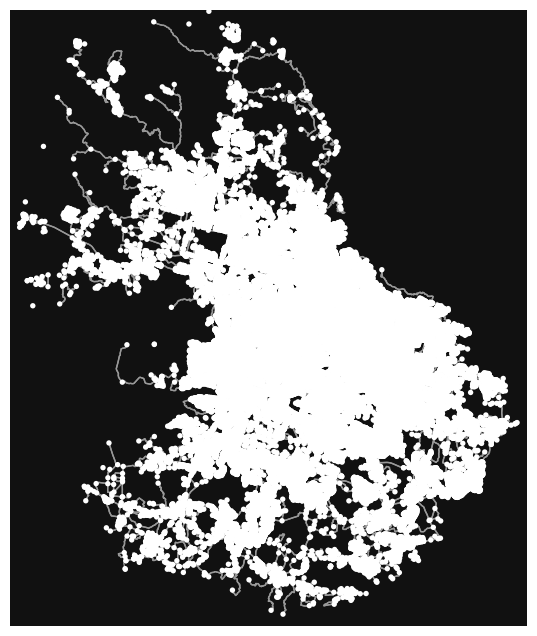

In [46]:
G_vial = ox.graph_from_place(ZMG, network_type="drive", retain_all=True)
fig, ax = ox.plot_graph(G_vial)

In [47]:
nodes_highway, edges_highway = ox.graph_to_gdfs(G_vial)
nodes_highway.to_file("nodes_highway.shp")
edges_highway.to_file("edges_highway.shp")

C:\Users\AP03542515\AppData\Local\Temp\3\ipykernel_26352\2777009188.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  nodes_highway.to_file("nodes_highway.shp")
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value '[1135990924, 1135990929, 1417643156, 1417643157, 1135990934, 1290072087, 1290072089, 1290072090, 1135990907, 1135990868, 1135990875, 1386358748, 1135990876, 1386358749, 1135990881, 1249584354, 1135990883, 1249584356, 1135990885, 1249584358, 1249584359, 1249584360, 1249584361, 1249584362, 1249584363, 1249584357, 1135990900, 1135990903, 1392865274, 1392865275]' of field osmid has been truncated to 254 characters.  This warning will not be emitted any more for that layer.
  ogr_write(


## Get __Railway__ Graph (transporte publico masivo aka.Lineas del Metro NOT SIMPLIFIED)
- __simplify = FALSE__, in order to obtain middle nodes in the line that are needed to host/serve as stop points of the railway line

#### Query "railway"~"light_rail|subway"
- brings __4 lineas de METRO, PERO con pedazos inservibles__
- Maniobras del Tren Electrico Urbano = cola al extremo de L2 (estacion de mantenimiento)
- Maniobras del Tren Eléctrico Urbano Tlajomulco = cola al extremo de L4 (sotano de mantenimiento)
- nan = fragmento en L4 donde como que se rompe la continuidad (malo)

### __Combine that query along with name__
- already checked that 4 LINEAS DEL METRO have correct name
- filter for those that have name in __Línea 1 del Tren Eléctrico Urbano, Línea 2 del Tren Eléctrico Urbano, Linea 3 del Tren Eléctrico Urbano, Linea 4 del Tren Eléctrico Urbano de Guadalajara__

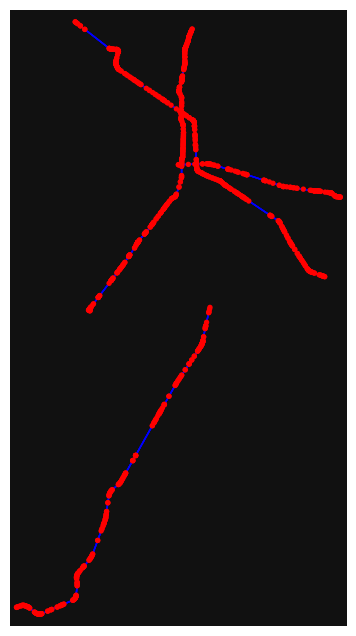

In [50]:
#cf_Massive_PuT = '["railway"~"light_rail|subway"]'
#custom_filter='["railway"~"light_rail|subway|tram|rail"]')

custom_filter = (
    '["railway"~"light_rail|subway|rail"]'
    '["name"~"Línea 1 del Tren Eléctrico Urbano|'
    'Línea 2 del Tren Eléctrico Urbano|'
    'Linea 3 del Tren Eléctrico Urbano|'
    'Linea 4 del Tren Eléctrico Urbano de Guadalajara"]'
)
G_railway = ox.graph_from_place(ZMG, 
                                retain_all=True,
                                simplify=False,
                                custom_filter=custom_filter)
fig, ax = ox.plot_graph(G_railway, node_color="red", edge_color="blue")

#### Check for 4 lineas del metro

In [40]:
nodes_rail, edges_rail = ox.graph_to_gdfs(G_railway)
edges_rail['name'].unique()

array(['Línea 1 del Tren Eléctrico Urbano',
       'Línea 2 del Tren Eléctrico Urbano',
       'Linea 4 del Tren Eléctrico Urbano de Guadalajara',
       'Linea 3 del Tren Eléctrico Urbano'], dtype=object)

In [36]:
nodes_rail.to_file("nodes_railway.shp")
edges_rail.to_file("edges_railway.shp")

C:\Users\AP03542515\AppData\Local\Temp\3\ipykernel_26352\287402583.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  nodes_rail.to_file("nodes_railway.shp")
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(


## __Combine__ both graphs __(highway & railway)__
- to create a single network

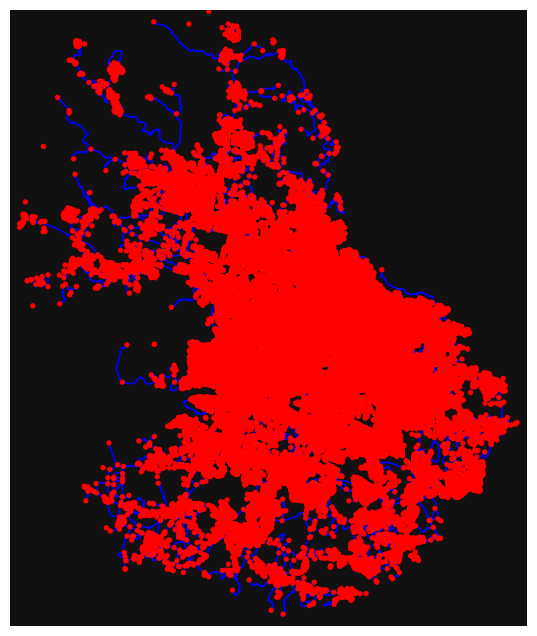

In [51]:
G_highway_railway = nx.compose(G_vial, G_railway)
fig, ax = ox.plot_graph(G_highway_railway, node_color="red", edge_color="blue")

## Get Nodes & Edges from Graph

In [60]:
nodes_composed, edges_composed = ox.graph_to_gdfs(G_highway_railway)

In [54]:
nodes_composed.to_file("nodes_Gcomposed.shp")
edges_composed.to_file("edges_Gcomposed.shp")

C:\Users\AP03542515\AppData\Local\Temp\3\ipykernel_26352\3633362680.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  nodes_composed.to_file("nodes_Gcomposed.shp")
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value '[1135990924, 1135990929, 1417643156, 1417643157, 1135990934, 1290072087, 1290072089, 1290072090, 1135990907, 1135990868, 1135990875, 1386358748, 1135990876, 1386358749, 1135990881, 1249584354, 1135990883, 1249584356, 1135990885, 1249584358, 1249584359, 1249584360, 1249584361, 1249584362, 1249584363, 1249584357, 1135990900, 1135990903, 1392865274, 1392865275]' of field osmid has been truncated to 254 characters.  This warning will not be emitted any more for that layer.
  ogr_write(


### __Restart IDS/numeration of Nodes__
- they have huge IDs int64 (osmid)
- visum only accepts int32
- create column node_id and start counting from 1

In [62]:
nodes_composed.reset_index(inplace=True)
edges_composed.reset_index(inplace=True)

In [65]:
nodes_composed['node_id'] = nodes_composed.index + 1
nodes_composed

,osmid,y,x,street_count,highway,junction,railway,ref,geometry,node_id
0,28751344,20.711533,-103.306309,3,NaN,NaN,NaN,NaN,POINT (-103.30631 20.71153),1
1,28753224,20.700650,-103.316645,3,NaN,NaN,NaN,NaN,POINT (-103.31665 20.70065),2
2,28757751,20.708531,-103.307371,3,NaN,NaN,NaN,NaN,POINT (-103.30737 20.70853),3
3,28757777,20.710096,-103.306817,4,crossing,NaN,NaN,NaN,POINT (-103.30682 20.7101),4
4,28768905,20.696546,-103.305728,3,NaN,NaN,NaN,NaN,POINT (-103.30573 20.69655),5
...,...,...,...,...,...,...,...,...,...,...
119305,12993641559,20.478431,-103.406874,2,NaN,NaN,NaN,NaN,POINT (-103.40687 20.47843),119306
119306,12993641560,20.478445,-103.406823,2,NaN,NaN,NaN,NaN,POINT (-103.40682 20.47845),119307
119307,13382581460,20.467172,-103.419976,2,NaN,NaN,NaN,NaN,POINT (-103.41998 20.46717),119308
119308,13382581461,20.467196,-103.420030,2,NaN,NaN,NaN,NaN,POINT (-103.42003 20.4672),119309


### __Create fromNode/toNode on Edges__
- map u & v on edged with column node_id of nodes_composed
- u = fromNode
- v = toNode
- u & v have old node ids (osmid of int64)
- get equivalent node_id (int32) of u & v

In [71]:
edges_composed['link_id'] = edges_composed.index + 1

In [73]:
# Create node map (which node_id corresponds to which osmid)
node_map = nodes_composed.set_index('osmid')['node_id']

# Create fromNode and toNode columns in edges_composed using the node_map
edges_composed['fromNode'] = edges_composed['u'].map(node_map)
edges_composed['toNode'] = edges_composed['v'].map(node_map)
edges_composed

,u,v,key,osmid,highway,junction,lanes,oneway,reversed,length,...,maxspeed,tunnel,ref,bridge,access,width,service,fromNode,toNode,link_id
0,28751344,1610958191,0,147983303,secondary,roundabout,2,True,False,22.824592,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,17484,1
1,28751344,28757777,0,824657718,tertiary,NaN,2,False,False,168.215321,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,4,2
2,28753224,1601906810,0,8148957,residential,NaN,2,False,False,47.170569,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,16689,3
3,28753224,1601906764,0,8148957,residential,NaN,2,False,True,48.083655,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,16665,4
4,28757751,6133633659,0,105072369,tertiary,NaN,4,False,False,129.726639,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,83509,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286877,13382581460,12257710044,0,1459191397,NaN,NaN,NaN,False,False,51.466278,...,NaN,NaN,NaN,yes,NaN,NaN,NaN,119308,119215,286878
286878,13382581461,10538357957,0,1324600322,NaN,NaN,NaN,False,False,171.702403,...,NaN,NaN,NaN,yes,NaN,NaN,NaN,119309,118992,286879
286879,13382581461,12257710043,0,1459191396,NaN,NaN,NaN,False,True,57.109967,...,NaN,NaN,NaN,yes,NaN,NaN,NaN,119309,119214,286880
286880,13656279161,5538433659,0,577828524,NaN,NaN,NaN,False,False,17.725030,...,NaN,NaN,NaN,yes,NaN,NaN,NaN,119310,118627,286881


## Try to get __Routes__

In [ ]:
tags = {
    
}

## Get __Stops/Stations__
- to verify if they are on the highway or railway graph

In [78]:
tags = {
    "public_transport": ["stop_position", "platform"],
    "highway": ["bus_stop"],
    "railway": ["station", "halt", "tram_stop"]
}

stops = ox.features_from_place(ZMG, tags) # has points, linestrings, and polygons
# Filter to only points
stop_points = stops[stops.geometry.type == "Point"]
stop_points.reset_index(inplace=True)


In [84]:
stop_points['node_id'] = stop_points['id'].map(node_map)
stop_points

c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,element,id,geometry,name,network,operator,public_transport,railway,subway,power,...,tunnel,indoor,roof:shape,roof:levels,underground,baby_feeding,area,aerialway,construction,node_id
0,node,340135806,POINT (-103.28557 20.66244),La Aurora,Mi Tren,SITEUR,stop_position,stop,yes,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,118139.0
1,node,340135807,POINT (-103.29729 20.66385),San Jacinto,Mi Tren,SITEUR,stop_position,stop,yes,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,118140.0
2,node,340135808,POINT (-103.3061 20.66526),San Andrés,Mi Tren,SITEUR,stop_position,stop,yes,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,118141.0
3,node,340135813,POINT (-103.31339 20.66749),Cristobal de Oñate,Mi Tren,SITEUR,stop_position,stop,yes,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,118142.0
4,node,340135815,POINT (-103.32252 20.67026),Oblatos,Mi Tren,SITEUR,stop_position,stop,yes,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,118143.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6502,node,12952466831,POINT (-103.34655 20.5883),Acueducto,NaN,SITEUR,stop_position,stop,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,119277.0
6503,node,12952466832,POINT (-103.34649 20.58827),Acueducto,NaN,SITEUR,stop_position,stop,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,119278.0
6504,node,13074937801,POINT (-103.34675 20.77224),Parada 636,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6505,node,13611018387,POINT (-103.51073 20.74615),Máquina de venta y recarga CUCBA,NaN,NaN,platform,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [116]:
def normalize_name(x):
    if isinstance(x, (list, tuple, np.ndarray)):
        return ", ".join(map(str, x)) if len(x) > 0 else None
    return x

edges_composed['name_normalized'] = edges_composed['name'].apply(normalize_name)

In [117]:
edges_composed.to_file("edges_Gcomposed_renumbered.shp")

C:\Users\AP03542515\AppData\Local\Temp\3\ipykernel_26352\2185087800.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  edges_composed.to_file("edges_Gcomposed_renumbered.shp")
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'name_normalized' to 'name_norma'
  ogr_write(
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value '[1135990924, 1135990929, 1417643156, 1417643157, 1135990934, 1290072087, 1290072089, 1290072090, 1135990907, 1135990868, 1135990875, 1386358748, 1135990876, 1386358749, 1135990881, 1249584354, 1135990883, 1249584356, 1135990885, 1249584358, 1249584359, 1249584360, 1249584361, 1249584362, 1249584363, 1249584357, 1135990900, 1135990903, 1392865274, 1392865275]' of field osmid has been truncated to 254 characters.  This warning will not be emitted any more for that layer.
  ogr_writ

In [87]:
edges_composed.to_file("edges_Gcomposed_renumbered.shp")
nodes_composed.to_file("nodes_Gcomposed_renumbered.shp")

c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value '[1135990924, 1135990929, 1417643156, 1417643157, 1135990934, 1290072087, 1290072089, 1290072090, 1135990907, 1135990868, 1135990875, 1386358748, 1135990876, 1386358749, 1135990881, 1249584354, 1135990883, 1249584356, 1135990885, 1249584358, 1249584359, 1249584360, 1249584361, 1249584362, 1249584363, 1249584357, 1135990900, 1135990903, 1392865274, 1392865275]' of field osmid has been truncated to 254 characters.  This warning will not be emitted any more for that layer.
  ogr_write(
C:\Users\AP03542515\AppData\Local\Temp\3\ipykernel_26352\403552353.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  nodes_composed.to_file("nodes_Gcomposed_renumbered.shp")
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(


In [108]:
stop_points_metro = stop_points[stop_points['node_id'].notna()]
stop_points_metro.to_file('stop_points_metro.shp')

C:\Users\AP03542515\AppData\Local\Temp\3\ipykernel_26352\3650132991.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  stop_points_metro.to_file('stop_points_metro.shp')
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'public_transport' to 'public_tra'
  ogr_write(
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'name:en' to 'name_en'
  ogr_write(
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'addr:housenumber' to 'addr_house'
  ogr_write(
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'addr:street' to 'addr_stree'
  ogr_write(
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.

In [88]:
stop_points.to_file("stops_withNodeIDs.shp")

C:\Users\AP03542515\AppData\Local\Temp\3\ipykernel_26352\2184853963.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  stop_points.to_file("stops_withNodeIDs.shp")
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'public_transport' to 'public_tra'
  ogr_write(
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'name:en' to 'name_en'
  ogr_write(
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'addr:housenumber' to 'addr_house'
  ogr_write(
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'addr:street' to 'addr_stree'
  ogr_write(
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723

### Stop Points __Analysis__
- __prediction:__ the only stop points that fall exactly on a node are stop points of lineas del metro (__TRUE y 1 extra__)
- __get__ values of network (MITREN, SiTren, MiTransporte) and define which ones are metro & which ones are bus/tram or fall under "red vial"
- __check__ that the ones with node_id are for metro (fall under "red ferrovial") (__YES & only 1 is from red vial__)
- __verify__ that the ones with node_id NULL dont have a stop point for network metro (MITREN, SiTren, idk which other is metro)
- __check__ number of stop points for each linea del metro & check stop points with ID match

In [93]:
stop_points[stop_points['node_id'].isna()].network.unique()

array([nan, 'Masai Mara', 'Mi Transporte', '629', '170B', '629 La Venta',
       'Mi Macro;Mi Transporte', 'Mi Transporte;Mi Macro',
       'Mi Macro;Mi Macro Periférico', 'Mi Macro Periférico;Mi Macro',
       'Mi Macro Periférico;Mi Transporte;Mi Macro',
       'Mi Transporte Eléctrico;Mi Macro;Mi Transporte',
       'Mi Macro Periférico;Mi Macro;Mi Transporte Eléctrico',
       'Mi Transporte;Mi Macro Periférico;Mi Macro', 'Mi Macro',
       'Mi Transporte;Mi Macro;Mi Transporte Eléctrico',
       'Mi Transporte Eléctrico;Mi Transporte;Mi Macro',
       'Mi Macro;Mi Macro Periférico;Mi Transporte Eléctrico',
       'Mi Macro;Mi Macro Periférico;Mi Transporte',
       'Mi Transporte;Mi Macro Periférico',
       'Mi Macro;Mi Transporte;Mi Transporte Eléctrico',
       'Mi Transporte;Mi Macro Periférico;Mi Macro;Mi Transporte Eléctrico',
       'Mi Transporte Eléctrico;Mi Transporte;Mi Macro Periférico;Mi Macro',
       'Mi Macro;Mi Transporte Eléctrico', 'SiTren;Mi Transporte',
      

## __Assign node_id to Stop Points of Red Vial__
- SP that do not fall exactly on a NODE
- SP that stayed NULL when I matched ID of stop_points to NODE ID of Nodes
- __USELESS bc 2 nodes can have the same nearest node__


In [96]:
# To which node_id from Gcomposed (graph highway + railway) do the osmid of nodes_highway correspond to?
nodes_highway.reset_index(inplace=True)
nodes_highway['node_id'] = nodes_highway['osmid'].map(node_map)
nodes_highway

,osmid,y,x,street_count,highway,junction,railway,ref,geometry,node_id
0,28751344,20.711533,-103.306309,3,NaN,NaN,NaN,NaN,POINT (-103.30631 20.71153),1
1,28753224,20.700650,-103.316645,3,NaN,NaN,NaN,NaN,POINT (-103.31665 20.70065),2
2,28757751,20.708531,-103.307371,3,NaN,NaN,NaN,NaN,POINT (-103.30737 20.70853),3
3,28757777,20.710096,-103.306817,4,crossing,NaN,NaN,NaN,POINT (-103.30682 20.7101),4
4,28768905,20.696546,-103.305728,3,NaN,NaN,NaN,NaN,POINT (-103.30573 20.69655),5
...,...,...,...,...,...,...,...,...,...,...
118098,13658896180,20.736149,-103.417884,1,NaN,NaN,NaN,NaN,POINT (-103.41788 20.73615),118099
118099,13659280148,20.737977,-103.412693,3,NaN,NaN,NaN,NaN,POINT (-103.41269 20.73798),118100
118100,13659280149,20.737937,-103.412436,1,NaN,NaN,NaN,NaN,POINT (-103.41244 20.73794),118101
118101,13686825281,20.745042,-103.439142,3,NaN,NaN,NaN,NaN,POINT (-103.43914 20.74504),118102


In [100]:
stops_withNo_nodeID = stop_points[stop_points['node_id'].isna()]
stops_withNo_nodeID['node_id'] = ox.distance.nearest_nodes(G_vial, X=stops_withNo_nodeID.geometry.x, Y=stops_withNo_nodeID.geometry.y)

c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [102]:
#stops_withNo_nodeID got on node_id the osmid of the nearest node in G_vial
# Now we can map those osmid to node_id in Gcomposed using node_map
stops_withNo_nodeID['node_id'] = stops_withNo_nodeID['node_id'].map(node_map)
stops_withNo_nodeID

c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,element,id,geometry,name,network,operator,public_transport,railway,subway,power,...,tunnel,indoor,roof:shape,roof:levels,underground,baby_feeding,area,aerialway,construction,node_id
7,node,1122575870,POINT (-103.29185 20.72662),Via servicio CFE,NaN,CFE,platform,NaN,NaN,generator,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55204
9,node,1518698843,POINT (-103.308 20.72875),Safari Masai Mara,NaN,NaN,platform,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35200
10,node,1518700246,POINT (-103.30757 20.72499),Estación 1,Masai Mara,Zoológico Guadalajara,platform,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,118072
11,node,1518700261,POINT (-103.30685 20.72874),Estación 2,Masai Mara,Zoológico Guadalajara,platform,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35213
12,node,1518700265,POINT (-103.30556 20.73241),Estación 3,Masai Mara,Zoológico Guadalajara,platform,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,118070
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6485,node,12425914216,POINT (-103.38726 20.72076),Zapopan Centro,NaN,NaN,platform,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30844
6501,node,12757315248,POINT (-103.3447 20.67097),Independencia,Mi Tren,SITEUR,station,station,yes,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15381
6504,node,13074937801,POINT (-103.34675 20.77224),Parada 636,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29368
6505,node,13611018387,POINT (-103.51073 20.74615),Máquina de venta y recarga CUCBA,NaN,NaN,platform,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83096


In [104]:
stops_withNo_nodeID.to_file("stops_redVial_withNodeIDs.shp")

C:\Users\AP03542515\AppData\Local\Temp\3\ipykernel_26352\220634659.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  stops_withNo_nodeID.to_file("stops_redVial_withNodeIDs.shp")
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'public_transport' to 'public_tra'
  ogr_write(
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'name:en' to 'name_en'
  ogr_write(
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'addr:housenumber' to 'addr_house'
  ogr_write(
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'addr:street' to 'addr_stree'
  ogr_write(
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyo